<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/medical_insurance_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_csv('/content/insurance (3).csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [51]:
print(df.shape)

(1338, 7)


In [52]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [54]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [55]:
print(df.duplicated().sum())

1


In [56]:
df.drop_duplicates(inplace=True)

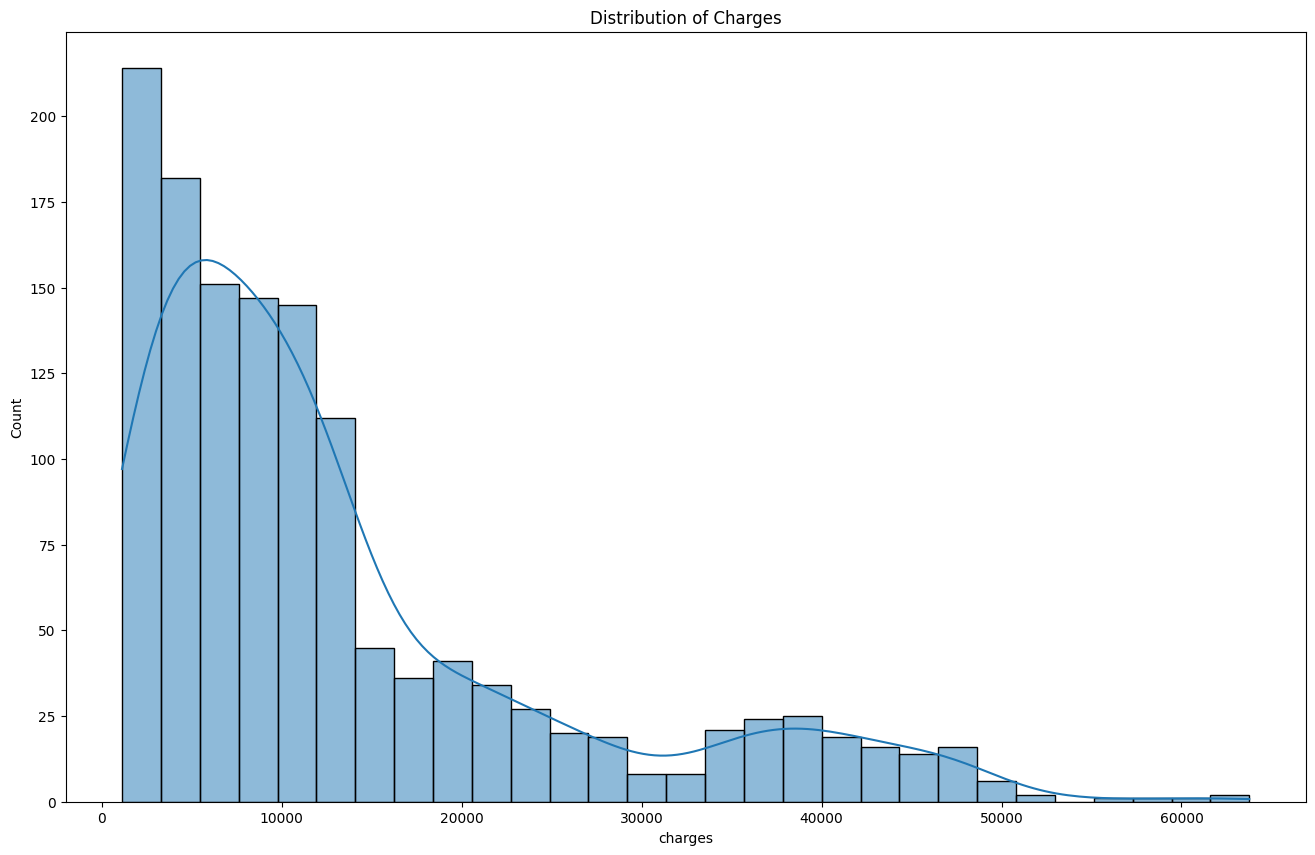

In [57]:
plt.figure(figsize=(16,10))
sns.histplot(df['charges'],kde=True)
plt.title('Distribution of Charges')
plt.show()

In [58]:
df['df_charges'] = np.log1p(df['charges'])

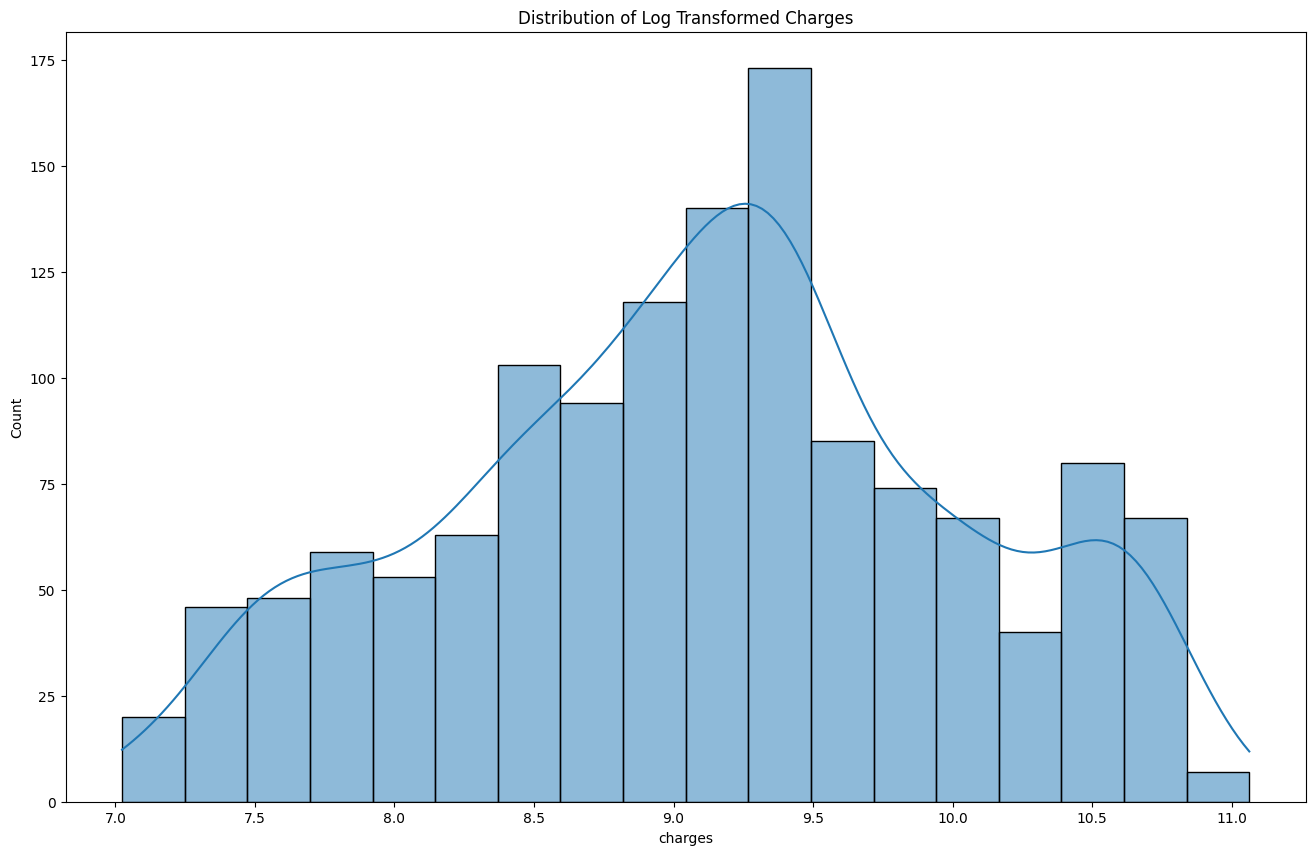

In [59]:
plt.figure(figsize=(16,10))

sns.histplot(df_charges, kde=True)

plt.title('Distribution of Log Transformed Charges')

plt.show()

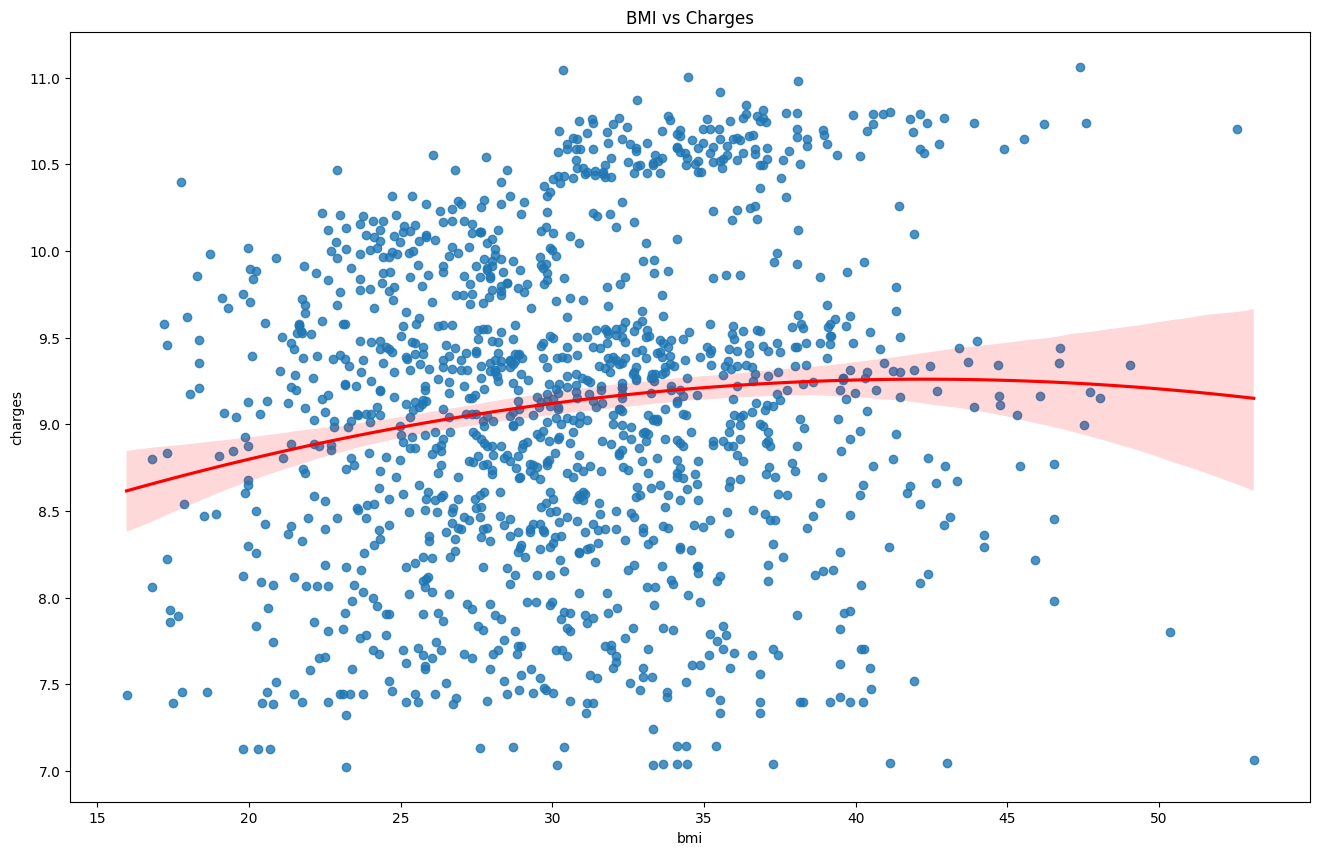

In [60]:
plt.figure(figsize=(16,10))

sns.regplot(
    x=df['bmi'],
    y=df_charges,
    order=2,
    line_kws={'color':'red'}
)
plt.title('BMI vs Charges')
plt.show()

<Axes: xlabel='smoker', ylabel='charges'>

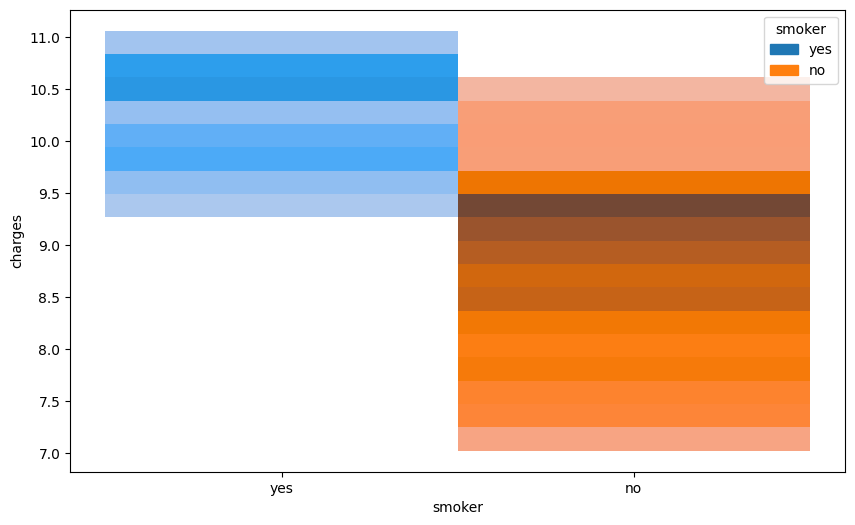

In [61]:
plt.figure(figsize=(10,6))
sns.histplot(
    x=df['smoker'],
    y=df_charges,
    hue='smoker',
    data=df

)

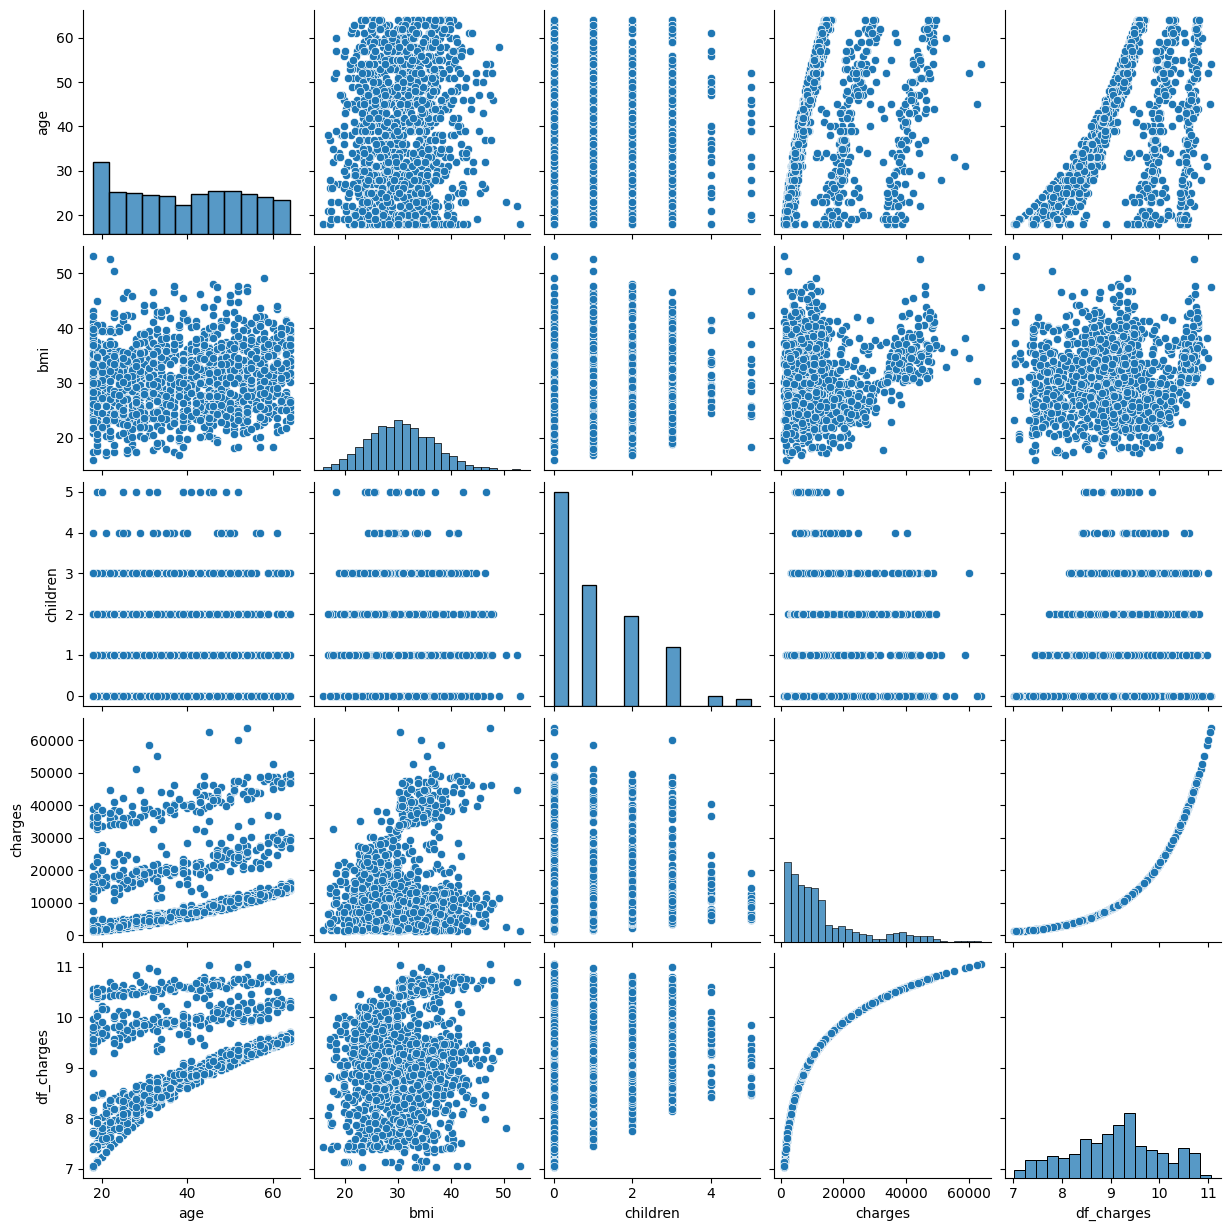

In [62]:
sns.pairplot(df)
plt.show()

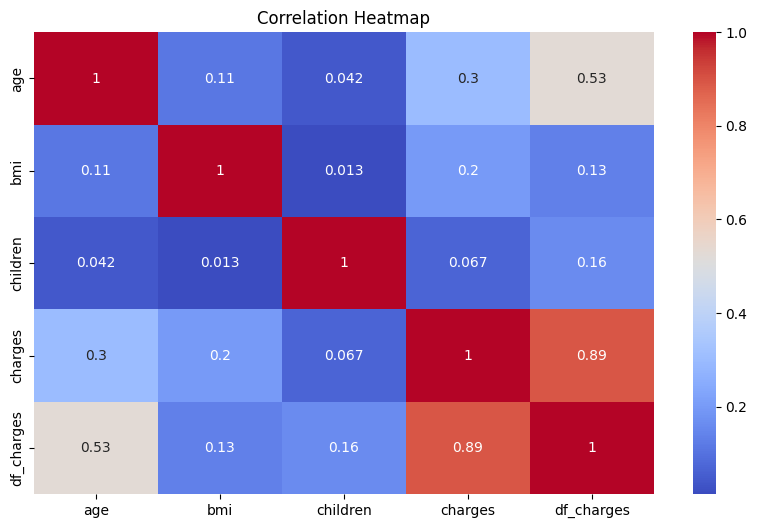

In [63]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [64]:
df = pd.get_dummies(df,drop_first=True)

In [65]:
df.head()

,age,bmi,children,charges,df_charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,9.734236,False,True,False,False,True
1,18,33.770,1,1725.55230,7.453882,True,False,False,True,False
2,28,33.000,3,4449.46200,8.400763,True,False,False,True,False
3,33,22.705,0,21984.47061,9.998137,True,False,True,False,False
4,32,28.880,0,3866.85520,8.260455,True,False,True,False,False


In [68]:
X = df.drop(['df_charges','charges'], axis=1)

y = df['df_charges']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [70]:
pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('poly', PolynomialFeatures(degree=2)),

    ('model', LinearRegression())

])

In [71]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('poly', PolynomialFeatures()),
                ('model', LinearRegression())])

In [72]:
y_pred = pipeline.predict(X_test)

In [73]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.19708875526552566


In [74]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.10577682660753054


In [75]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.3252334955190356


In [76]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8860025822294546


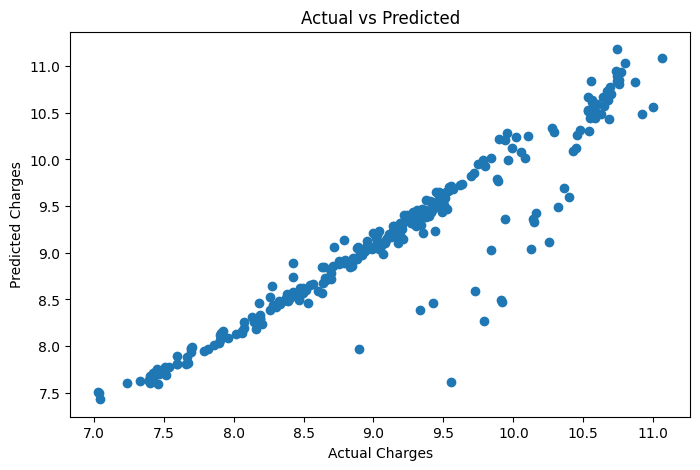

In [77]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

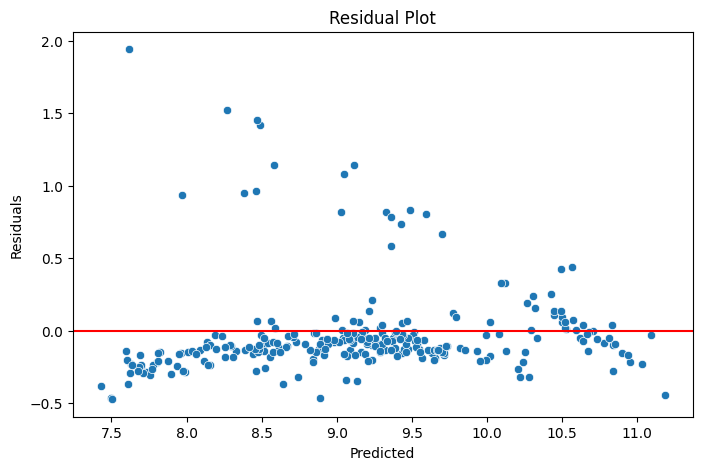

In [78]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

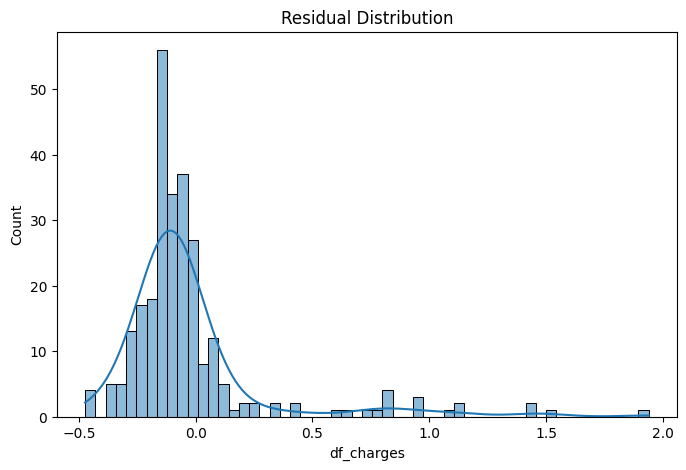

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [80]:
train_scores = []
test_scores = []

degrees = [1,2,3,4]

for d in degrees:

    pipeline = Pipeline([

        ('scaler', StandardScaler()),

        ('poly', PolynomialFeatures(degree=d)),

        ('model', LinearRegression())

    ])

    pipeline.fit(X_train, y_train)

    train_scores.append(
        pipeline.score(X_train, y_train)
    )

    test_scores.append(
        pipeline.score(X_test, y_test)
    )

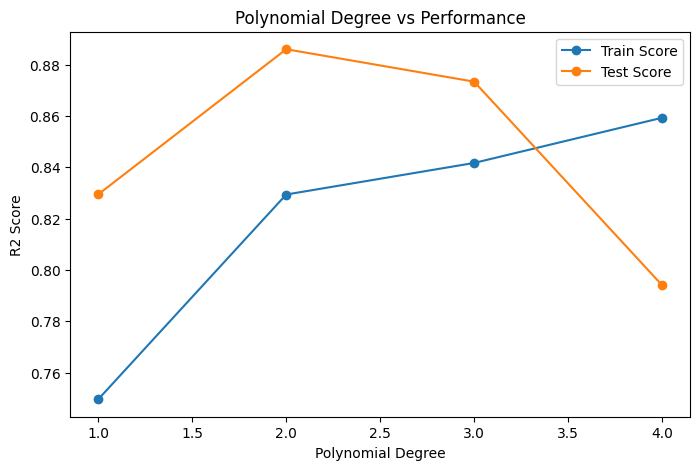

In [81]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_scores,
    marker='o',
    label='Train Score'
)

plt.plot(
    degrees,
    test_scores,
    marker='o',
    label='Test Score'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")

plt.title("Polynomial Degree vs Performance")

plt.legend()

plt.show()

In [82]:
new_data = pd.DataFrame({

    'age':[45],
    'bmi':[30.5],
    'children':[2],
    'sex_male':[1],
    'smoker_yes':[1],
    'region_northwest':[0],
    'region_southeast':[1],
    'region_southwest':[0]

})

prediction = pipeline.predict(new_data)

print("Predicted Insurance Charges:", prediction)

Predicted Insurance Charges: [10.42959572]


In [83]:
import joblib

joblib.dump(
    pipeline,
    'insurance_polynomial_model.pkl'
)

['insurance_polynomial_model.pkl']

In [84]:
loaded_model = joblib.load(
    'insurance_polynomial_model.pkl'
)

In [85]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly, y)

coefficients = pd.DataFrame({

    'Feature': poly.get_feature_names_out(),

    'Coefficient': model.coef_

})

print(coefficients.head(20))

                 Feature   Coefficient
0                      1 -8.751717e-12
1                    age  5.548100e-02
2                    bmi  4.552757e-02
3               children  3.492393e-01
4               sex_male -1.967443e-01
5             smoker_yes  6.575502e-01
6       region_northwest -1.635634e-02
7       region_southeast -6.871931e-02
8       region_southwest -1.289464e-01
9                  age^2 -1.734801e-04
10               age bmi -1.383671e-04
11          age children -4.283509e-03
12          age sex_male  4.616750e-03
13        age smoker_yes -3.283601e-02
14  age region_northwest  2.849387e-03
15  age region_southeast  8.139352e-03
16  age region_southwest  7.986018e-03
17                 bmi^2 -5.272829e-04
18          bmi children -4.994799e-05
19          bmi sex_male  3.013382e-03
